In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Visualizacion de datos.

In [71]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [72]:
df.shape

(117415, 20)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [74]:
df.duplicated().sum()

np.int64(121)

In [75]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.duplicated().sum()

np.int64(0)

### Observaciones
>
>Logramo visualizar los datos. En  cada linea podemos entender que es una compra. algunas comparten el mismo numero de ticket lo que nos da a entender que cada linea es un articulo que se compro, algunas variables categoricas parecen ser numericas, las estudiaremos para modificarlas si se necesita. Encontramos unos duplicados pero para descartarlas tomamos la decision de evaluarlas antes para tener una decision mas acertada. Tenemos 20 columnas y estudiaremos cada una de ellas.
>
>En el analisis inicial notamos tambien que la fila `Fisc. Numero` no tiene ningun valor en ninguna columna. asi que procederemos a borrar directamente esa columna.
>Tambien 

In [76]:
df.drop(["Fisc. Numero"],axis=1, inplace=True)

## Analisis de variables.

### Analisis de variables categoricas

>Empezaremos evaluando las variables categoricas para evaluar que contiene cada una de ellas.

In [77]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha',
 'Tipo Mov.',
 'Fac. Tipo',
 'Tipo Pago',
 'Precio',
 'Producto',
 'Sub. Total',
 'Rubro',
 'Cobertura',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Total Gravado',
 'Total sin Gravar']

In [ ]:
df[cat_variables].head()

,Fecha,Tipo Mov.,Fac. Tipo,Tipo Pago,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,E,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,01/01/25 01.59.21,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,01/01/25 02.01.59,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,01/01/25 02.04.14,F,B,E,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,01/01/25 02.08.35,F,B,E,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"


In [79]:
df["Tipo Mov."].value_counts()

Tipo Mov.
F    117294
Name: count, dtype: int64

In [80]:
df["Fac. Tipo"].value_counts()

Fac. Tipo
B    117131
A       163
Name: count, dtype: int64

In [81]:
df["Tipo Pago"].value_counts()

Tipo Pago
E    117294
Name: count, dtype: int64

In [82]:
df["Producto"].value_counts()

Producto
GEN LP IBUPROFENO blister 600 mg x 10      1925
GEN LP OMEPRAZOL blister 20 mg x 15        1203
ASPIRINA PREVENT comp.cub.enterica x 50    1149
TAFIROL 1G X 8 (unica)                      870
TAFIROL 1 G comp.ran.x 50                   699
                                           ... 
NOCTE 10 10 mg comp.x 30                      1
AVENT CHUPETE (unica)                         1
CEPILLO ORAL B (unica)                        1
PAMPERS PANTS PREMIUM CARE XGD                1
APOSITO IQP (unica)                           1
Name: count, Length: 7675, dtype: int64

In [83]:
df["Rubro"].value_counts()

Rubro
FARMACIA           108277
PERFUMERIA           8916
NO ESPECIFICADO       101
Name: count, dtype: int64

In [84]:
df["Desc. Adic."].value_counts()

Desc. Adic.
0             115152
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

In [85]:
df["IVA"].value_counts()

IVA
0              94474
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
1818,81            1
2965,42562         1
3529,132959        1
1662,644628        1
4252,447517        1
Name: count, Length: 4217, dtype: int64

In [86]:
df["Total Gravado"].value_counts()

Total Gravado
0              94474
826,446281       982
2479,338843      673
4132,231405      658
3719,008264      641
               ...  
8661               1
14121,07438        1
16805,39504        1
7917,355372        1
20249,75008        1
Name: count, Length: 4217, dtype: int64

In [87]:
df["Total sin Gravar"].value_counts()

Total sin Gravar
0           22003
3500         1410
5000         1376
4000         1316
3000          758
            ...  
9783            1
6942,08         1
26376,02        1
19010           1
9646,28         1
Name: count, Length: 26927, dtype: int64

#### Procederemos a ejecutar las siguientes acciones.

> - Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
> - Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [88]:
df.drop(["Tipo Mov.", "Tipo Pago"],axis=1, inplace=True)

In [89]:
fals_obj = ["Precio","Sub. Total","Cobertura","Desc. Adic.","Total. Cliente","IVA","Total Gravado","Total sin Gravar"]

df[fals_obj] = df[fals_obj].astype(str).apply(lambda col: col.str.replace(",", "."))
df[fals_obj] = df[fals_obj].apply(pd.to_numeric)

In [90]:
df[fals_obj]

,Precio,Sub. Total,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0000,9344.00
1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0000,8174.96
2,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0000,8174.96
3,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0000,8086.82
4,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0000,26750.12
...,...,...,...,...,...,...,...,...
117289,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0000,5000.00
117290,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0000,13641.20
117291,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,13223.1405,0.00
117292,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0000,36758.39


In [91]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha', 'Fac. Tipo', 'Producto', 'Rubro']

#### Procederemos a ejecutar las siguientes acciones.

>Analizaremos las variables `Fecha`, `Fac. Tipo`, `Producto`, `Rubro` que tenemos como categoricas para entender las variables a mayor profundidad.

In [92]:
df["Fecha"]

0         01/01/25 01.13.46
1         01/01/25 01.59.21
2         01/01/25 02.01.59
3         01/01/25 02.04.14
4         01/01/25 02.08.35
                ...        
117289    23/12/25 10.23.06
117290    23/12/25 10.25.57
117291    23/12/25 10.34.31
117292    23/12/25 10.38.49
117293    23/12/25 10.53.40
Name: Fecha, Length: 117294, dtype: object

In [93]:
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%y %H.%M.%S")

In [94]:
df["Fecha"].head()

0   2025-01-01 01:13:46
1   2025-01-01 01:59:21
2   2025-01-01 02:01:59
3   2025-01-01 02:04:14
4   2025-01-01 02:08:35
Name: Fecha, dtype: datetime64[ns]

In [95]:
df["num_semana"] = df["Fecha"].dt.isocalendar().week.astype(int)

In [96]:
df_copy = df.copy()

<Axes: xlabel='hora'>

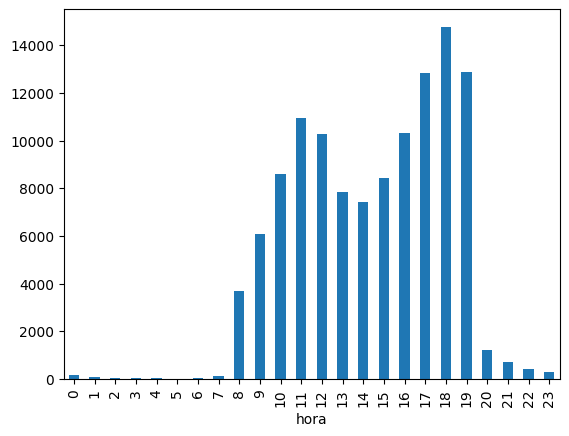

In [97]:
df_copy["hora"] = df_copy["Fecha"].dt.hour
df_copy["hora"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='day_num'>

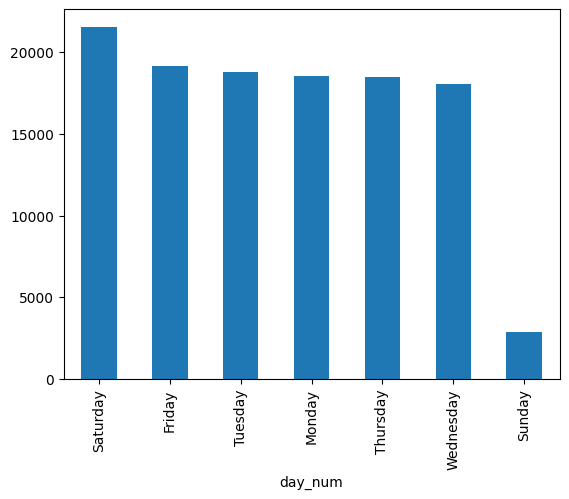

In [98]:
df_copy["day_num"] = df_copy["Fecha"].dt.day_name()
df_copy["day_num"].value_counts().plot(kind="bar")

<Axes: xlabel='Fecha'>

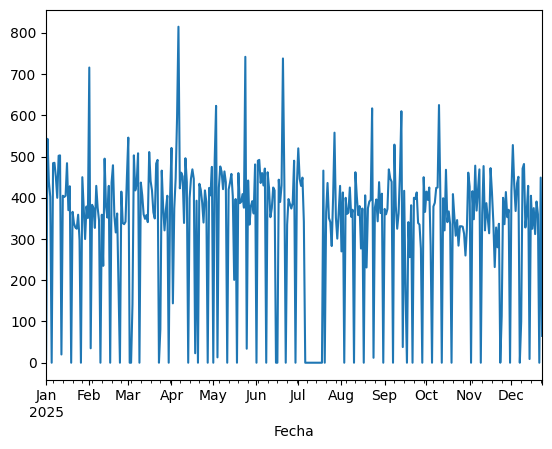

In [99]:
por_dia = df_copy.set_index("Fecha").resample("D").size()
por_dia.plot()

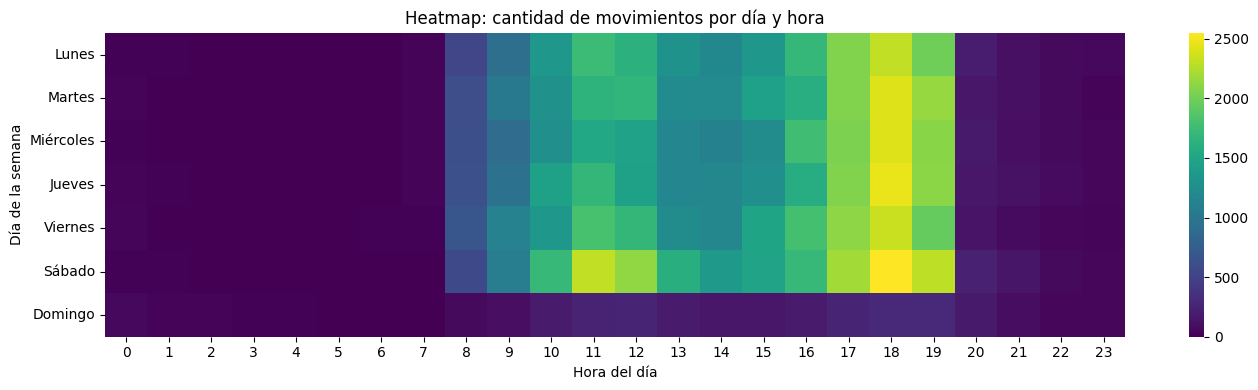

In [100]:
df_copy["day_num"] = df_copy["Fecha"].dt.dayofweek
df_copy["hour"] = df_copy["Fecha"].dt.hour

heat = pd.crosstab(df_copy["day_num"], df_copy["hour"])
heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)

dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="viridis") 
plt.yticks(ticks=[i+0.5 for i in range(7)], labels=dias, rotation=0)
plt.xticks(rotation=0)
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Heatmap: cantidad de movimientos por día y hora")
plt.tight_layout()
plt.show()

In [101]:
cat_variables.remove("Fecha")
cat_variables.remove("Producto")

<Axes: xlabel='Rubro', ylabel='count'>

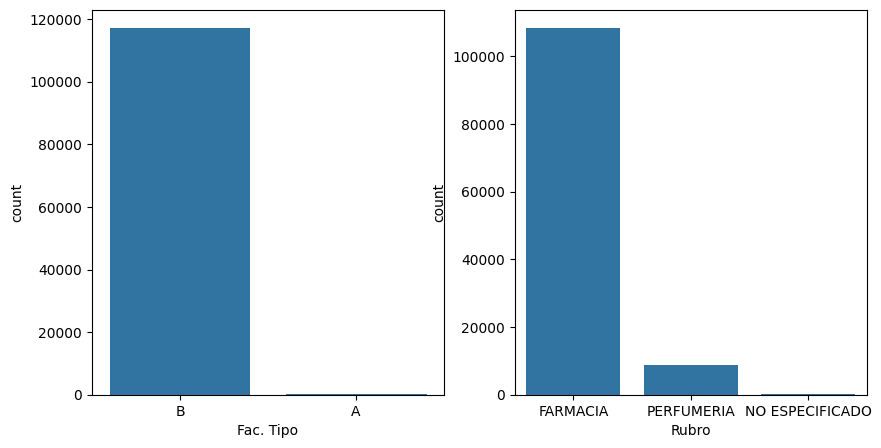

In [102]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(data=df, x=cat_variables[0], ax=axis[0])
sns.countplot(data=df, x=cat_variables[1], ax=axis[1])


#### Variable `Producto`

>Esta variable tiene muchos valores que son complicados de leer, como la trabajaremos a profundidad organizaremos y explicaremos en este espacio las decisiones que tomamos.
>
>Empezaremos por pasar todas las variables a minusculas y cambiar las ","(comas) por "."(puntos).

In [103]:
df["Producto"] = df["Producto"].fillna("").astype(str).str.lower().str.replace(",", ".", regex=False)
df["Producto"].value_counts()


Producto
gen lp ibuprofeno blister 600 mg x 10             1925
gen lp omeprazol blister 20 mg x 15               1203
aspirina prevent comp.cub.enterica x 50           1149
tafirol 1g x 8 (unica)                             870
tafirol 1 g comp.ran.x 50                          699
                                                  ... 
proair bronquial 500/50 cáps.p/inh.x 60+aplic.       1
flevomax 1000 mg comp.rec.x 30                       1
pampers pants premium care xgd                       1
aposito iqp (unica)                                  1
venda 7.5x2.5  (unica)                               1
Name: count, Length: 7672, dtype: int64

>Procederemos a borrar todos los productos que se vendieron menos de 100 veces en todo el año de datos que tenemos.
>Tambien haremos una revision a los nombres que tengan menos de 13 letras para verificar si queda algun error de tipografia donde no podamos sacar mas datos sobre el producto.

In [104]:
df = df[df["Producto"].map(df["Producto"].value_counts()) >= 100].copy()


In [105]:
mask = df["Producto"].fillna("").astype(str).str.len().le(12)
count_rows = mask.sum()
count_rows
df.loc[mask, "Producto"].astype(str).str.strip().value_counts()

Producto
dove (unica)    115
gum (unica)     108
Name: count, dtype: int64

In [106]:
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10            1925
gen lp omeprazol blister 20 mg x 15              1203
aspirina prevent comp.cub.enterica x 50          1149
tafirol 1g x 8 (unica)                            870
tafirol 1 g comp.ran.x 50                         699
                                                 ... 
aucic 1% sol.oft.x 10 ml                          101
ibupirac 600 capsula blanda cáps.blandas x 50     101
kala md comp.rec.x 28                             101
acc lp borato de sodio x 25 gr                    101
alplax 2 mg comp.x 30                             100
Name: count, Length: 189, dtype: int64

#### Observaciones

>Hasta este paso quitamos todos los productos que tuvieran menos de 12 ventas en todo el año y realizamos una revision de las variables que tuvieran menos de 12 letras, esto para filtrar los errores tipograficos como nombres cortos que no aporten nada. Aun asi no encontramos ninguno y continuamos.
>
>Nuestro siguiente paso es realizar una categorizacion a partir de la columna `Producto` donde crearemos la columna `product, dose, quantity` para clasificar los productos y poder entender mejor los datos.

In [107]:
df[["product", "dose", "quantity"]] = pd.NA

>Empezaremos poniendo las dosis segun los productos, para eso investigaremos sobre la nomenclatura de las dosis en argentina y crearemos un filtro que itere.

In [108]:
dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)                 # ✅ fix aquí
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

df["dose"] = df["Producto"].str.findall(dose_pat).str.join(", ")
df["dose"] = df["dose"].str.replace(r"(?i)(?<!\w)(unica|única)(?!\w)", "UNICA", regex=True)
df["dose"] = df["dose"].replace("", np.nan)


>Verificamos que productos quedan en blanco despues de nuestro filtro.

In [109]:
df[
    df["dose"].fillna("").eq("")
][["Producto", "Rubro", "dose"]].value_counts()

Series([], Name: count, dtype: int64)

In [110]:
df[["Producto", "dose"]].value_counts()

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
                                                       ... 
guantes (unica)                           UNICA         103
ultra corega crema sin sabor pomo x 20 g  20 g          103
vivita forte antigripal pouch x 1 x 5 g   5 g           103
aucic 1% sol.oft.x 10 ml                  1%            101
alplax 2 mg comp.x 30                     2 mg          100
Name: count, Length: 117, dtype: int64

>obtuvimos todas las dosis posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `quantity`.

In [111]:
prod = df["Producto"].fillna("").astype(str)

qty_pat = r"""(?ix)(
    
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b           

  
    \b(?:pomo|frasco|vial|amp(?:olla)?|sobre|sachet)\s*x?\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b

  
    \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b


    \bx\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b\d{1,3}x\d{1,3}\b
)"""

df["quantity"] = prod.str.findall(qty_pat).str.join(", ")
df["quantity"] = df["quantity"].replace("", np.nan)


/tmp/ipykernel_2910/3579741549.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["quantity"] = df["quantity"].replace("", np.nan)


In [112]:
df[["Producto", "dose"]].value_counts().head(20)

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
corbis 5 mg comp.rec.x 30                 5 mg          471
alikal (unica)                            UNICA         451
t4 montpellier 75 75 mcg comp.x 50        75 mcg        446
t4 montpellier 50 50 mcg comp.x 50        50 mcg        423
t4 montpellier 100 100 mcg comp.x 50      100 mcg       386
gen lp ibuprofeno blister 400 mg x 10     400 mg        368
acemuk 600 mg tab.eferv.x 10              600 mg        350
lotrial 10 mg comp.x 60                   10 mg         344
gen lp loratadina blister 10 mg x 10      10 mg         336
losacor 50 mg comp.rec.x 60               50 mg         306
carey (unica)                             UNICA 

>obtuvimos todas las cantidades posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `product`.

In [113]:
prod = df["Producto"].fillna("").astype(str)

# --- 1) patrones a eliminar (dosis y cantidades/presentación) ---

dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

qty_remove_pat = r"""(?ix)(
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b
  | \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b
  | \bx\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b\d{1,3}x\d{1,3}\b
)"""

# --- 2) base: quitar dose + quantity del texto ---
p = (prod
     .str.replace(dose_pat, " ", regex=True)
     .str.replace(qty_remove_pat, " ", regex=True)
)

# --- 3) FIXES específicos ---
# 3.1) quitar números sueltos al final (ej: "... seda 50" -> "... seda")
p = p.str.replace(r"(?ix)\s+\d{1,4}(?:\.\d+)?\s*$", " ", regex=True)

# 3.2) quitar 'x' suelta (ej: "cr x" -> "cr")
p = p.str.replace(r"(?ix)(?<!\w)x(?!\w)", " ", regex=True)

# 3.3) quitar el número repetido que coincide con la dosis (diurex 25 25 mg -> diurex)
dose_num = df["dose"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)

def drop_repeated_num(text, num):
    if not isinstance(num, str) or num == "" or num.lower() == "nan":
        return text
    return re.sub(rf"(?<!\w){re.escape(num)}(?!\w)", " ", text)

p = pd.Series(
    (drop_repeated_num(t, n) for t, n in zip(p.tolist(), dose_num.tolist())),
    index=df.index
)

# --- 4) limpieza final: puntuación y espacios ---
df["product"] = (p
    .str.replace(r"[^\w\sáéíóúñü]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", np.nan)
)

# opcional: colapsa repeticiones tipo "gel gel" -> "gel"
df["product"] = df["product"].str.replace(
    r"(?ix)\b(\w+)\b(?:\s+\1\b)+", r"\1", regex=True
)

In [114]:
df["product"].isna().sum()


np.int64(0)

In [115]:
import re
import unicodedata
import pandas as pd

# ---------- Helpers ----------
def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm(s) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = strip_accents(s)
    s = re.sub(r"\s+", " ", s)
    return s


EXACT = {
    
    "ibuprofeno": "ibuprofeno",
    "paracetamol": "paracetamol",
    "omeprazol": "omeprazol",
    "losartan": "losartán",
    "enalapril": "enalapril",
    "bisoprolol": "bisoprolol",
    "alprazolam": "alprazolam",
    "clonazepam": "clonazepam",
    "lactulosa": "lactulosa",
    "loratadina": "loratadina",
    "diclofenaco": "diclofenaco",
    "acetilcisteina": "acetilcisteína",
    "rosuvastatina": "rosuvastatina",
    "levotiroxina": "levotiroxina",
    "acido acetilsalicilico": "ácido acetilsalicílico",
    "acido acetilsalicilico + cafeina": "ácido acetilsalicílico + cafeína",
    "diclofenaco + pridinol": "diclofenaco + pridinol",
    "propinox + clonixinato de lisina": "propinox + clonixinato de lisina",
    "butilbromuro de hioscina + metamizol": "butilbromuro de hioscina + metamizol",
    "amoxicilina": "amoxicilina",
    "amoxicilina + acido clavulanico": "amoxicilina + ácido clavulánico",
    "colecalciferol (vitamina d3)": "colecalciferol (vitamina d3)",

    "tafirol": "paracetamol",
    "tafirol 500": "paracetamol",
    "tafirol forte": "paracetamol",
    "tafirol blister": "paracetamol",
    "geniol comp": "paracetamol",
    "mejoral paracetamol": "paracetamol",
    "paracetamol bayer": "paracetamol",
    "paracetamol raffo": "paracetamol",
    "paracetamol lazar": "paracetamol",
    "paracetamol teva": "paracetamol",

    "aspirina prevent comp cub enterica": "ácido acetilsalicílico",
    "bayaspirina": "ácido acetilsalicílico",
    "bayaspirina forte": "ácido acetilsalicílico",
    "aspirinetas": "ácido acetilsalicílico",
    "cafiaspirina": "ácido acetilsalicílico + cafeína",

    "t4 montpellier": "levotiroxina",
    "euthyrox": "levotiroxina",

    "lotrial": "enalapril",
    "corbis": "bisoprolol",
    "losacor": "losartán",
    "paxon": "losartán",
    "alplax": "alprazolam",
    "alplax net": "alprazolam",

    "rivotril": "clonazepam",
    "clonagin": "clonazepam",
    "clonagin sl": "clonazepam",
    "diocam": "clonazepam",
    "diocam sl": "clonazepam",

    "lactulon jbe": "lactulosa",

    "buscapina": "butilbromuro de hioscina",
    "buscapina fem": "butilbromuro de hioscina",
    "buscapina perlas": "butilbromuro de hioscina",
    "buscapina duo": "butilbromuro de hioscina",
    "buscapina duo got": "butilbromuro de hioscina",
    "buscapina compuesta": "butilbromuro de hioscina + metamizol",
    "buscapina compositum comp rec": "butilbromuro de hioscina + metamizol",

    "sertal": "propinox",
    "sertal perlas": "propinox",
    "sertal gts": "propinox",
    "sertal compuesto": "propinox + clonixinato de lisina",
    "sertal compuesto vl": "propinox + clonixinato de lisina",

    "ibupirac": "ibuprofeno",
    "actron 600 rapida accion caps gelat blanda": "ibuprofeno",
    "fabogesic 600 rapida accion cáps gelat blanda": "ibuprofeno",

    "acemuk": "acetilcisteína",
    "osteodyn": "colecalciferol (vitamina d3)",
    "osteodyn sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 100000 ui": "colecalciferol (vitamina d3)",
    "sterogyl f a beb": "colecalciferol (vitamina d3)",
    "sinlip": "rosuvastatina",

    "gadopril": "enalapril",

  
    "valium": "diazepam",
    "zoloft": "sertralina",
    "asertral": "sertralina",
    "lexotanil": "bromazepam",
    "lexapro": "escitalopram",
    "aropax": "paroxetina",
    "paxil cr": "paroxetina",
    "dramamine": "dimenhidrinato",
    "reliveran": "metoclopramida",
    "novalgina": "metamizol",
    "novalgina jbe": "metamizol",
    "bactrim": "sulfametoxazol + trimetoprima",
    "bactrim forte": "sulfametoxazol + trimetoprima",
    "glucophage": "metformina",
    "glucophage xr comp lib prol": "metformina",
    "dbi metformina": "metformina",
    "dbi ap metformina": "metformina",
    "forxiga": "dapagliflozina",
    "lipitor": "atorvastatina",
    "atorvastatin richet": "atorvastatina",
    "atorvastan": "atorvastatina",
    "ventolin hfa aer inh c": "salbutamol",
    "ventolin sol p nebul": "salbutamol",
    "salbutral aer": "salbutamol",
    "atrovent hfa aerosol hfa": "ipratropio",
    "seretide diskus dosis": "fluticasona + salmeterol",
    "symbicort turbuhaler dosis": "budesonida + formoterol",
    "anoro ellipta pvo inh": "umeclidinio + vilanterol",

    # Antibióticos marcas comunes
    "amoxidal": "amoxicilina",
    "amoxidal ped susp": "amoxicilina",
    "amoxidal duo": "amoxicilina + ácido clavulánico",
    "amoxidal duo susp": "amoxicilina + ácido clavulánico",
    "optamox duo": "amoxicilina + ácido clavulánico",
    "optamox duo susp": "amoxicilina + ácido clavulánico",
    "amixen clavulanico": "amoxicilina + ácido clavulánico",
    "amixen duo": "amoxicilina + ácido clavulánico",
    "amoclav duo": "amoxicilina + ácido clavulánico",
}


GENERIC_PATTERNS = [
    (r"\bibuprofeno\b", "ibuprofeno"),
    (r"\bparacetamol\b", "paracetamol"),
    (r"\bdiclofenac", "diclofenaco"),
    (r"\bnaproxeno\b", "naproxeno"),
    (r"\bketorolac\b", "ketorolac"),
    (r"\ballopurinol\b", "allopurinol"),
    (r"\batenolol\b", "atenolol"),
    (r"\bpropranolol\b", "propranolol"),
    (r"\bcarvedilol\b", "carvedilol"),
    (r"\bclopidogrel\b", "clopidogrel"),
    (r"\bmetformina\b", "metformina"),
    (r"\batorvastat", "atorvastatina"),
    (r"\brosuvastatina\b", "rosuvastatina"),
    (r"\bespironolactona\b", "espironolactona"),
    (r"\bfurosemida\b", "furosemida"),
    (r"\blosartan\b", "losartán"),
    (r"\benalapril\b", "enalapril"),
    (r"\bbisoprolol\b", "bisoprolol"),
    (r"\bomeprazol\b", "omeprazol"),
    (r"\blesomeprazol\b", "esomeprazol"),
    (r"\blevotiroxina\b", "levotiroxina"),
    (r"\bamoxicilina\b", "amoxicilina"),
    (r"\bcefalexina\b", "cefalexina"),
    (r"\bclindamicina\b", "clindamicina"),
    (r"\bciprofloxacina\b", "ciprofloxacina"),
    (r"\bnorfloxacina\b", "norfloxacina"),
    (r"\bazitromicina\b", "azitromicina"),
    (r"\bfluconazol\b", "fluconazol"),
    (r"\bnistatina\b", "nistatina"),
    (r"\bsildenafil\b", "sildenafil"),
    (r"\baciclovir\b", "aciclovir"),
    (r"\bcarbamazepina\b", "carbamazepina"),
    (r"\blamotrig", "lamotrigina"),
    (r"\bmemantina\b", "memantina"),
    (r"\bfinaster", "finasterida"),
    (r"\btamsulosina\b", "tamsulosina"),
    (r"\bsertralina\b", "sertralina"),
    (r"\bfluoxet", "fluoxetina"),
    (r"\bes(c|s)italopram\b", "escitalopram"),
    (r"\bparoxetina\b", "paroxetina"),
    (r"\bdiazepam\b", "diazepam"),
    (r"\bbromazepam\b", "bromazepam"),
    (r"\brisperid", "risperidona"),
    (r"\bquetiapin", "quetiapina"),
    (r"\bhaloperidol\b", "haloperidol"),
    (r"\bloratadina\b", "loratadina"),
    (r"\bdifenhidramina\b", "difenhidramina"),
    (r"\bsalbutamol\b", "salbutamol"),
    (r"\bipratropio\b", "ipratropio"),
    (r"\bfluticasona\b", "fluticasona"),
    (r"\bsalmeterol\b", "salmeterol"),
    (r"\bbudesonida\b", "budesonida"),
    (r"\bformoterol\b", "formoterol"),
    (r"\bmometasona\b", "mometasona"),
    (r"\bmetoclopramida\b", "metoclopramida"),
    (r"\bmetamizol\b", "metamizol"),
    (r"\bacetilcisteina\b", "acetilcisteína"),
    (r"\blactulosa\b", "lactulosa"),
    (r"\bcolecalciferol\b", "colecalciferol (vitamina d3)"),
    (r"\bcalcitriol\b", "calcitriol"),
    (r"\blidocaina\b", "lidocaína"),
    (r"\bterbinafina\b", "terbinafina"),
    (r"\bbeta(histina)?\b", "betahistina"),
    (r"\bdapaglifloz", "dapagliflozina"),
]


AMBIGUOUS = {
    "carey",
    "diurex", "diurex a",
    "qura", "qura plus",
    "migral", "migral ii", "migral compuesto", "migral compositum",
    "alikal", "alikal expend c prosp",
    "refrianex", "refrianex compuesto",
    "mylanta", "mylanta extra", "mylanta ii", "mylanta simple liq", "mylanta limon",
    "mylanta frut silv", "mylanta tabletas", "mylanta extra tableta",
    "supradyn forte", "supradyn pronatal", "supradyn forte eferv nar s az",
    "berocca plus",
    "uvasal sob doble", "uvasal naranja sob doble", "uvasal limon sob doble",
    "uvasal naranja fco", "uvasal fco plast",
    "next", "next forte", "next plus",
    "vick vitapyrena", "vick vitapyrena forte miel limon", "vick forte",
    "vick vaporub lata", "vick vaporub pote",
    "redoxon eferv limon", "redoxon eferv",
    "redoxitos plus sachets gomitas", "redoxitos naranja masticables sachets gomitas",
    "centrum mujer", "centrum silver",
    "corbis d", "lotrial d", "losacor a", "losacor d", "gadopril d",
    "paxon d", "losartan richet trzb",
}

# ---------- Mapeo ----------
def map_active(product_name: str):
    s0 = norm(product_name)
    if not s0:
        return "Desconocido", "empty"

 
    if s0 in AMBIGUOUS:
        return "Desconocido", "ambiguous_or_unknown"

    
    if s0.startswith("gen lp "):
        rest = s0.replace("gen lp ", "", 1).strip()
        rest = rest.replace("clavulanico", "acido clavulanico")

        if rest in EXACT:
            return EXACT[rest], "gen_lp_exact"

        for pat, active in GENERIC_PATTERNS:
            if re.search(pat, rest):
                return active, "gen_lp_pattern"

        return "Desconocido", "gen_lp_unresolved"

   
    if s0 in EXACT:
        return EXACT[s0], "exact"

  
    for pat, active in GENERIC_PATTERNS:
        if re.search(pat, s0):
            return active, "pattern"

 
    if re.search(r"\b(acc lp|perfumeria|accesorio|guantes|curita|curitas|barbijo|test|algodon|gasa|jeringa|venda|cepillo|colgate|dove|nivea|gillette|labello|listerine|rexona|ponds|garnier|pantene)\b", s0):
        return "Desconocido", "non_drug_or_device"

    return "Desconocido", "unknown"


mapped = df["product"].apply(map_active)


active = mapped.apply(lambda x: x[0])


mask = active != "Desconocido"
df.loc[mask, "product"] = active[mask]


print("Reemplazados:", int(mask.sum()))



Reemplazados: 21159


In [116]:
df

,Fecha,Fac. Tipo,Fac. Suc.,Fac. Nun.,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,...,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,num_semana,product,dose,quantity
8,2025-01-01 07:46:36,B,0,379930,2,3500.00,accesorio (unica),7000.00,FARMACIA,0.00,...,0.0,7000.00,1214.876033,21,5785.123967,0.00,1,accesorio,UNICA,NaN
9,2025-01-02 08:08:38,B,0,379931,1,3430.00,qura plus comp.rec.x 20,3430.00,FARMACIA,0.00,...,343.0,3087.00,0.000000,0,0.000000,3430.00,1,qura plus,NaN,NaN
13,2025-01-02 08:44:01,B,0,379935,1,4500.00,acc lp gasa esteril no 5 caja 10 x 10,4500.00,FARMACIA,0.00,...,0.0,4500.00,780.991736,21,3719.008264,0.00,1,acc lp gasa esteril no 5 caja,NaN,NaN
15,2025-01-02 08:44:01,B,0,379935,1,1000.00,acc lp agua oxigenada 10 vol\tx 100 cc,1000.00,FARMACIA,0.00,...,0.0,1000.00,173.553719,21,826.446281,0.00,1,acc lp agua oxigenada 10 vol,NaN,NaN
16,2025-01-02 08:44:01,B,0,379935,1,800.00,curitas (unica),800.00,FARMACIA,0.00,...,0.0,800.00,0.000000,0,0.000000,800.00,1,curitas,UNICA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117281,2025-12-23 10:03:35,B,0,455857,2,18005.59,levotiroxina gsk 75 mcg comp.x 50,36011.18,FARMACIA,17077.54,...,0.0,18933.64,0.000000,0,0.000000,36011.18,52,levotiroxina,75 mcg,NaN
117286,2025-12-23 10:17:33,B,0,455860,1,14800.00,ultra corega crema sin sabor pomo x 70 g,14800.00,FARMACIA,0.00,...,0.0,14800.00,2568.595041,21,12231.404960,0.00,52,ultra corega crema sin sabor pomo,70 g,NaN
117288,2025-12-23 10:23:06,B,0,455861,8,13500.00,mylanta extra comp.mast.x 24,4500.00,FARMACIA,0.00,...,0.0,4500.00,0.000000,0,0.000000,4500.00,52,mylanta extra,NaN,NaN
117289,2025-12-23 10:23:06,B,0,455861,1,5000.00,colgate (unica),5000.00,FARMACIA,0.00,...,0.0,5000.00,0.000000,0,0.000000,5000.00,52,colgate,UNICA,NaN


In [117]:
df[["product"]].value_counts()

product                                               
ibuprofeno                                                3162
paracetamol                                               2602
levotiroxina                                              2588
ácido acetilsalicílico                                    1378
omeprazol                                                 1203
                                                          ... 
bisofec                                                    103
acc lp tela antialergica 3m de1 25 s racionador microp     102
acc lp borato de sodio                                     101
aucic sol oft                                              101
kala md                                                    101
Name: count, Length: 134, dtype: int64

In [118]:
(df["product"] != "Desconocido").sum()


np.int64(41107)

In [119]:
df.drop(columns=["quantity"], errors="ignore", inplace=True)

### Analisis de variables numericas

In [120]:
num_variables = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_variables

['Fac. Suc.',
 'Fac. Nun.',
 'Cant.',
 'Precio',
 'Sub. Total',
 'Cobertura',
 'Ajustes',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Tasa Iva',
 'Total Gravado',
 'Total sin Gravar',
 'num_semana']

In [121]:
df[num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Fac. Suc.,41107.0,0.000000,0.000000,0.00,0.00,0.00,0.000,0.00000
Fac. Nun.,41107.0,417039.481548,22146.952437,379930.00,398028.00,415255.00,436511.000,455862.00000
Cant.,41107.0,1.433722,1.743754,0.00,1.00,1.00,1.000,48.00000
Precio,41107.0,10384.595184,9065.898011,30.00,4000.00,7730.00,13800.000,98000.00000
Sub. Total,41107.0,10813.035250,9741.467582,0.00,4100.00,7780.24,13974.980,160000.00000
Cobertura,41107.0,4450.618100,7984.717235,-157953.92,0.00,0.00,6842.331,104049.86000
Ajustes,41107.0,0.000000,0.000000,0.00,0.00,0.00,0.000,0.00000
Desc. Adic.,41107.0,12.203385,312.505848,-31312.40,0.00,0.00,0.000,14380.43000
Total. Cliente,41107.0,6350.213765,5570.640485,0.00,2883.63,5000.00,8150.000,178298.57000
IVA,41107.0,123.055567,414.069019,0.00,0.00,0.00,0.000,27768.59504


In [122]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,41107,2025-06-22 13:42:13.804412672,2025-01-01 07:46:36,2025-03-29 08:23:06,2025-06-12 17:07:58,2025-09-19 08:49:54,2025-12-23 10:25:57,NaN
Fac. Suc.,41107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fac. Nun.,41107.0,417039.481548,379930.0,398028.0,415255.0,436511.0,455862.0,22146.952437
Cant.,41107.0,1.433722,0.0,1.0,1.0,1.0,48.0,1.743754
Precio,41107.0,10384.595184,30.0,4000.0,7730.0,13800.0,98000.0,9065.898011
Sub. Total,41107.0,10813.03525,0.0,4100.0,7780.24,13974.98,160000.0,9741.467582
Cobertura,41107.0,4450.6181,-157953.92,0.0,0.0,6842.331,104049.86,7984.717235
Ajustes,41107.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Desc. Adic.,41107.0,12.203385,-31312.4,0.0,0.0,0.0,14380.43,312.505848
Total. Cliente,41107.0,6350.213765,0.0,2883.63,5000.0,8150.0,178298.57,5570.640485


KeyboardInterrupt: 

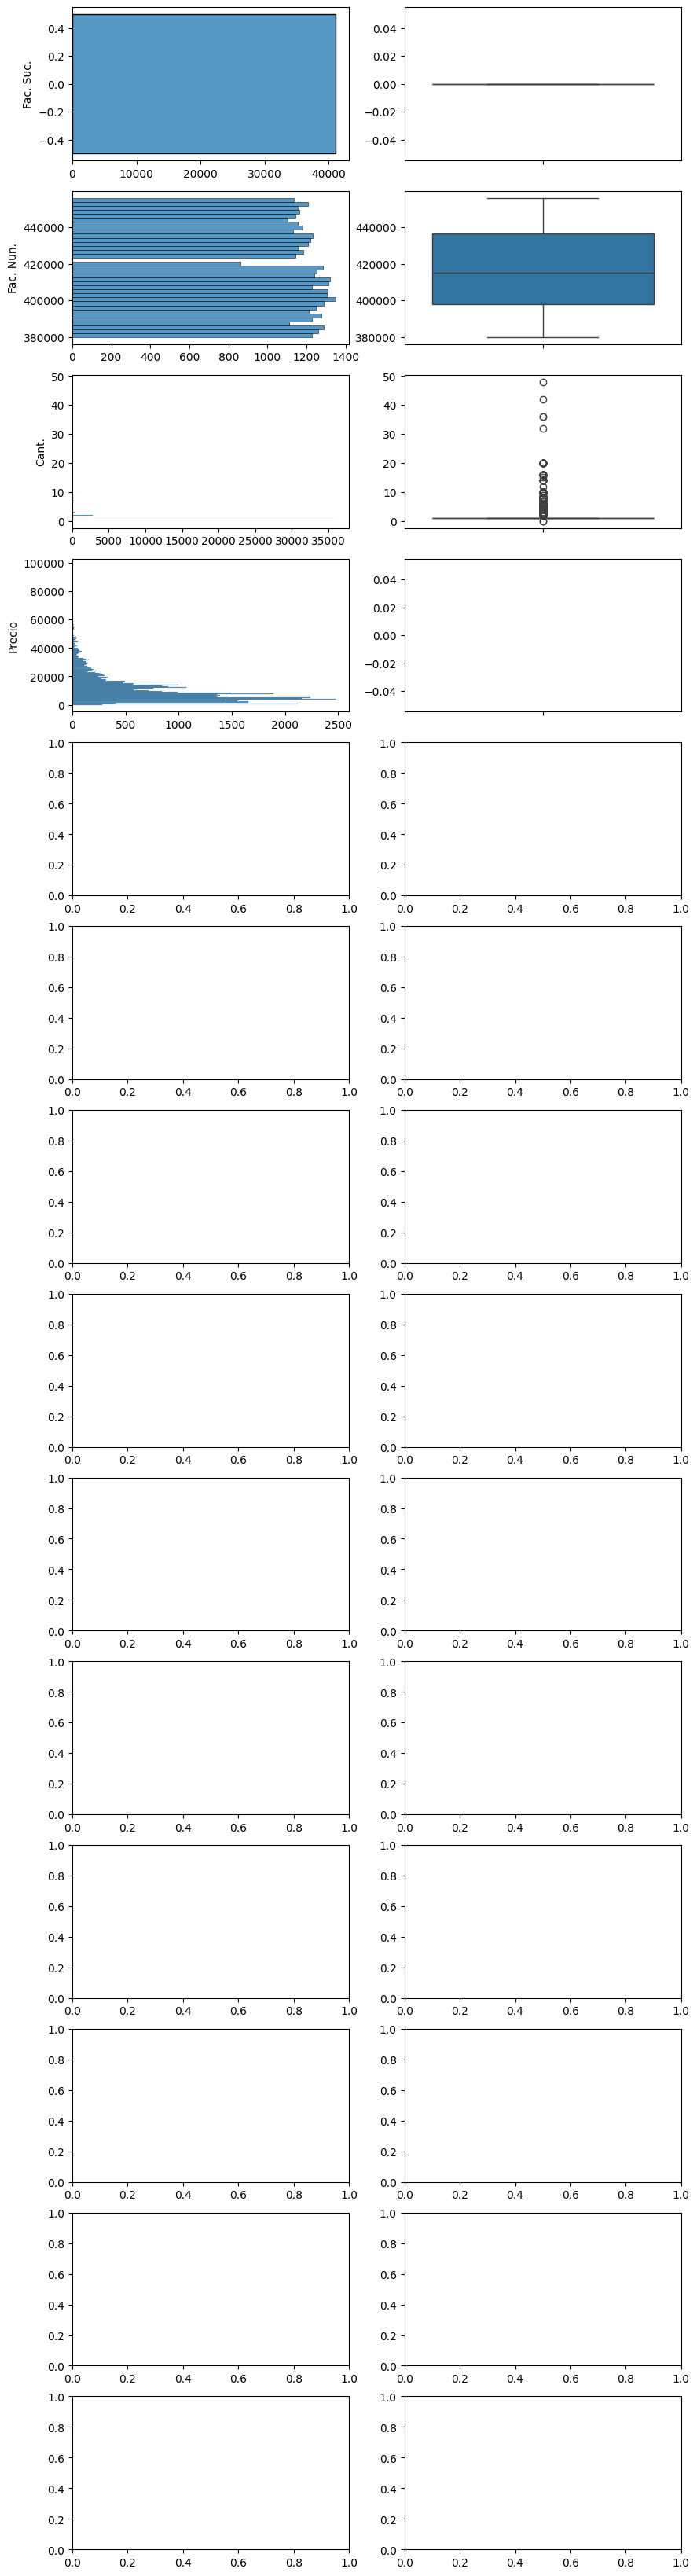

In [123]:
fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

#### Observaciones.

`Fac. Suc.` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Fac. Nun.` - Es el numero de factura, como un id, tampoco nos aporta mucho a lo que buscamos.    
`Cant.` - Aunque la mayoria tienen como valor 1, el resto de outliner parecen ser reales, la conservaremos para tratarla detalladamente mas adelante.  
`Precio` - Es el precio por unidad que tiene un producto  
`Sub. Total` - Es el resultado de multiplicar el precio por cantidad   
`Cobertura` - Es lo que cubre la seguridad social.   
`Ajustes` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Desc. Adic.` - Aunque la mayoria de los valores estan en 0, tiene numeros en negativos y positivos, tambien revisaremos a profundidad.  
`Total. Cliente` -  La mayoria de valores esta entre 0 y 25000, tiene varios outliners que debemos tomar en cuenta.  
`IVA` -  Esta variable va desde el 0 al 160000, tiene sentido ya que sera el iva por producto.  
`Tasa Iva` - esta entre 0, 10% y 21%    
`Total Gravado` -  los valores principalmente estan en 0, pero notamos algunos outliners que revisaremos a detalle  
`Total sin Gravar` -   Los valores estan entre 0 y 60000 aproximadamente, encontramos varios outliners que analizaremos lo que nos dice mas adelante.  

In [ ]:
df = df.drop(columns=["Fac. Suc", "Fac. Nun.", "Ajustes"], errors="ignore")

In [ ]:
df[["Producto", "Precio", "Sub. Total", "Cant.", "Cobertura", "Desc. Adic.", "Tasa Iva", "IVA","Total Gravado", "Total sin Gravar", "Total. Cliente"]].head(10)

,Producto,Precio,Sub. Total,Cant.,Cobertura,Desc. Adic.,Tasa Iva,IVA,Total Gravado,Total sin Gravar,Total. Cliente
8,accesorio (unica),3500.0,7000.0,2,0.0,0.0,21,1214.876033,5785.123967,0.0,7000.0
9,qura plus comp.rec.x 20,3430.0,3430.0,1,0.0,343.0,0,0.000000,0.000000,3430.0,3087.0
13,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
15,acc lp agua oxigenada 10 vol\tx 100 cc,1000.0,1000.0,1,0.0,0.0,21,173.553719,826.446281,0.0,1000.0
16,curitas (unica),800.0,800.0,1,0.0,0.0,0,0.000000,0.000000,800.0,800.0
20,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
22,gen lp ibuprofeno blister 600 mg x 10,3500.0,3500.0,1,0.0,0.0,0,0.000000,0.000000,3500.0,3500.0
31,rhinal gts.x 30 ml,5360.0,5360.0,1,0.0,0.0,0,0.000000,0.000000,5360.0,5360.0
32,sertal compuesto comp.rec.x 20,11200.0,5600.0,10,0.0,0.0,0,0.000000,0.000000,5600.0,5600.0
33,ventolin hfa aer.inh.c/aplic.x200ds.,17470.0,17470.0,1,0.0,0.0,0,0.000000,0.000000,17470.0,17470.0


### Observaciones. Hasta este punto tenemos informacion suficiente para poder, según el modelo y el target, usar los datos para hacer predicciones de ML.

## Objetivos o targets a predecir.

### Objetivo 1: Predecir cantidad de productos vendidos por semana.

>Con los datos que tenemos nos parece viable hacer predicciones de ventas de productos. Ajustaremos y limpiaremos el DataSet en una copia para dejar los datos que tenemos hasta aca para otro tipo de predicciones.

In [ ]:
df_obj_one = df.copy()

In [ ]:
df_obj_one.head(10)

,Fecha,Fac. Tipo,Fac. Suc.,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,num_semana,product,dose
8,2025-01-01 07:46:36,B,0,2,3500.0,accesorio (unica),7000.0,FARMACIA,0.0,0.0,7000.0,1214.876033,21,5785.123967,0.0,1,accesorio,UNICA
9,2025-01-02 08:08:38,B,0,1,3430.0,qura plus comp.rec.x 20,3430.0,FARMACIA,0.0,343.0,3087.0,0.000000,0,0.000000,3430.0,1,qura plus,NaN
13,2025-01-02 08:44:01,B,0,1,4500.0,acc lp gasa esteril no 5 caja 10 x 10,4500.0,FARMACIA,0.0,0.0,4500.0,780.991736,21,3719.008264,0.0,1,acc lp gasa esteril no 5 caja,NaN
15,2025-01-02 08:44:01,B,0,1,1000.0,acc lp agua oxigenada 10 vol\tx 100 cc,1000.0,FARMACIA,0.0,0.0,1000.0,173.553719,21,826.446281,0.0,1,acc lp agua oxigenada 10 vol,NaN
16,2025-01-02 08:44:01,B,0,1,800.0,curitas (unica),800.0,FARMACIA,0.0,0.0,800.0,0.000000,0,0.000000,800.0,1,curitas,UNICA
20,2025-01-02 09:00:10,B,0,1,4500.0,acc lp gasa esteril no 5 caja 10 x 10,4500.0,FARMACIA,0.0,0.0,4500.0,780.991736,21,3719.008264,0.0,1,acc lp gasa esteril no 5 caja,NaN
22,2025-01-02 09:00:10,B,0,1,3500.0,gen lp ibuprofeno blister 600 mg x 10,3500.0,FARMACIA,0.0,0.0,3500.0,0.000000,0,0.000000,3500.0,1,ibuprofeno,600 mg
31,2025-01-02 09:08:40,B,0,1,5360.0,rhinal gts.x 30 ml,5360.0,FARMACIA,0.0,0.0,5360.0,0.000000,0,0.000000,5360.0,1,rhinal gts,NaN
32,2025-01-02 09:08:40,B,0,10,11200.0,sertal compuesto comp.rec.x 20,5600.0,FARMACIA,0.0,0.0,5600.0,0.000000,0,0.000000,5600.0,1,propinox + clonixinato de lisina,NaN
33,2025-01-02 09:08:40,B,0,1,17470.0,ventolin hfa aer.inh.c/aplic.x200ds.,17470.0,FARMACIA,0.0,0.0,17470.0,0.000000,0,0.000000,17470.0,1,salbutamol,NaN


In [ ]:
cols_drop = ["Sub. Total", "IVA", "Tasa Iva", "Total Gravado",
            "Total sin Gravar", "Total. Cliente", "Cobertura",
            "Desc. Adic.", "Producto", "Fac. Tipo", "Fac. Suc.",
            "Precio", "Rubro", "Fecha", "dose"]

df_obj_one = df.drop(columns=cols_drop, errors="ignore")

In [ ]:
df_obj_one

,Cant.,num_semana,product
8,2,1,accesorio
9,1,1,qura plus
13,1,1,acc lp gasa esteril no 5 caja
15,1,1,acc lp agua oxigenada 10 vol
16,1,1,curitas
...,...,...,...
117281,2,52,levotiroxina
117286,1,52,ultra corega crema sin sabor pomo
117288,8,52,mylanta extra
117289,1,52,colgate


Para el modelo necesitamos visualizar de la lista de productos semanal cuales fueron las ventas, pero si no hubo sucede que no podemos visualizarlo. para eso crearemos un df que rellenaremos con los datos del `df_obj_one` que ya tenemos.

In [ ]:
products = df_obj_one["product"].dropna().unique()
weeks = df_obj_one["num_semana"].dropna().unique()
base = pd.MultiIndex.from_product([products, weeks], names=["product", "num_semana"]).to_frame(index=False)
base["cantidad"] = 0

In [ ]:
base

,product,num_semana,cantidad
0,accesorio,1,0
1,accesorio,2,0
2,accesorio,3,0
3,accesorio,4,0
4,accesorio,5,0
...,...,...,...
6829,vick forte,48,0
6830,vick forte,49,0
6831,vick forte,50,0
6832,vick forte,51,0


In [ ]:
df_obj_one = (df_obj_one.groupby(["num_semana","product"], as_index=False)["Cant."]
         .sum()
         .rename(columns={"Cant.":"y"}))

In [ ]:
base = (base
               .drop(columns=["cantidad"], errors="ignore")   
               .merge(df_obj_one, on=["product", "num_semana"], how="left"))

base["y"] = base["y"].fillna(0).astype(int)

base.head()

,product,num_semana,y
0,accesorio,1,5
1,accesorio,2,11
2,accesorio,3,20
3,accesorio,4,5
4,accesorio,5,3


In [ ]:
base.loc[base["num_semana"] == 1]

,product,num_semana,y
0,accesorio,1,5
51,qura plus,1,1
102,acc lp gasa esteril no 5 caja,1,5
153,acc lp agua oxigenada 10 vol,1,3
204,curitas,1,2
...,...,...,...
6579,acc lp alcohol puro,1,0
6630,treg,1,0
6681,next forte,1,0
6732,vivita forte antigripal pouch,1,0


In [ ]:
base = base.sort_values(["product", "num_semana"]).reset_index(drop=True)


for l in range(1, 9):
    base[f"y_lag{l}"] = base.groupby("product")["y"].shift(l)

lag_cols = [f"y_lag{l}" for l in range(1, 9)]
past_mean = (base.groupby("product")["y"]
               .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
               .reset_index(level=0, drop=True))
for c in lag_cols:
    base[c] = base[c].fillna(past_mean)
base[lag_cols] = base[lag_cols].fillna(0)
base[lag_cols] = np.ceil(base[lag_cols]).astype(int)


In [ ]:
base.loc[base["product"] == "acc lp agua oxigenada 10 vol"].head(10)

,product,num_semana,y,y_lag1,y_lag2,y_lag3,y_lag4,y_lag5,y_lag6,y_lag7,y_lag8
0,acc lp agua oxigenada 10 vol,1,3,0,0,0,0,0,0,0,0
1,acc lp agua oxigenada 10 vol,2,8,3,3,3,3,3,3,3,3
2,acc lp agua oxigenada 10 vol,3,17,8,3,6,6,6,6,6,6
3,acc lp agua oxigenada 10 vol,4,9,17,8,3,10,10,10,10,10
4,acc lp agua oxigenada 10 vol,5,10,9,17,8,3,10,10,10,10
5,acc lp agua oxigenada 10 vol,6,7,10,9,17,8,3,10,10,10
6,acc lp agua oxigenada 10 vol,7,5,7,10,9,17,8,3,9,9
7,acc lp agua oxigenada 10 vol,8,10,5,7,10,9,17,8,3,9
8,acc lp agua oxigenada 10 vol,9,9,10,5,7,10,9,17,8,3
9,acc lp agua oxigenada 10 vol,10,9,9,10,5,7,10,9,17,8


In [ ]:
base.to_csv("../data/processed/df", index=False)